### Etapa 1: Preparação do Ambiente e Planejamento

In [76]:
# Bibliotecas de terceiros
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos da biblioteca padrão do Python
import os
import re
import json
from datetime import datetime, timedelta
from IPython.display import display

### Etapa 2: Ingestão de Dados (ETL - Extract)

<h5 style="color: #7ac1f4;">
RF01 – Criar ou Carregar o Dataset de Vendas
</h5>

In [77]:
# Carregar o CSV
df = pd.read_csv('../databases/vendas.csv')

### Etapa 3: Inspeção Estrutural (EDA Inicial)

<h5 style="color: #7ac1f4;">
RF02 – Inspecionar e Descrever os Dados
</h5>

In [78]:
# Função para inspecionar os dados
def inspecionar_dados(df):
    """Exibe as informações estruturais do DataFrame com tabelas renderizadas."""
    print("=== INSPEÇÃO INICIAL DO DATASET ===")
    
    # 1. Shape
    print(f'Shape: O dataframe tem [{df.shape[0]}] linhas e [{df.shape[1]}] colunas.\n')
    
    # 2. As 5 primeiras linhas (renderizadas)
    print("Primeiras 5 linhas:")
    display(df.head()) 
    
    # 3. As 5 últimas linhas (renderizadas)
    print("\nÚltimas 5 linhas:")
    display(df.tail())
    
    # 4. Tipos das colunas
    print("\nTipos das colunas:")
    display(df.dtypes.to_frame(name="Tipo de Dado"))
    
    # 5. Valores nulos
    print("\nValores nulos por coluna:")
    display(df.isnull().sum().to_frame(name="Qtd Nulos"))

In [79]:
# Chamada da função (sem dar return no df para não duplicar no final)
inspecionar_dados(df)

=== INSPEÇÃO INICIAL DO DATASET ===
Shape: O dataframe tem [200] linhas e [8] colunas.

Primeiras 5 linhas:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2025-05-21,cliente#016,Mouse,Perifericos,Sudeste,2.0,102.90
1,2,2025-09-16,Cliente_039,Notebook,Computadores,Norte,NaN,3204.57
2,3,2025-03-23,Cliente_045,Tablet,Celulares,Centro-Oeste,1.0,1939.76
3,4,2025-11-06,Cliente_017,Notebook,Computadores,Norte,6.0,3864.87
4,5,2025-07-05,Cliente_037,Tablet,Celulares,Sul,10.0,2008.14



Últimas 5 linhas:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
195,196,2025-06-04,CLIENTE-038,Monitor,Computadores,Centro-Oeste,5.0,NaN
196,197,2025-09-15,Cliente_046,Tablet,Celulares,Sul,3.0,1748.92
197,198,2025-08-21,Cliente_048,Smartphone,Celulares,Sul,3.0,2185.60
198,199,2025-11-02,Cliente_006,Headset,Perifericos,Norte,4.0,368.94
199,200,2025-03-18,Cliente_011,Teclado,Perifericos,Sudeste,4.0,255.45



Tipos das colunas:


,Tipo de Dado
id_venda,int64
data_venda,str
cliente,str
produto,str
categoria,str
regiao,str
quantidade,float64
preco_unitario,float64



Valores nulos por coluna:


,Qtd Nulos
id_venda,0
data_venda,0
cliente,0
produto,0
categoria,0
regiao,0
quantidade,10
preco_unitario,4


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_venda        200 non-null    int64  
 1   data_venda      200 non-null    str    
 2   cliente         200 non-null    str    
 3   produto         200 non-null    str    
 4   categoria       200 non-null    str    
 5   regiao          200 non-null    str    
 6   quantidade      190 non-null    float64
 7   preco_unitario  196 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 12.6 KB


In [81]:
df.head(10)

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2025-05-21,cliente#016,Mouse,Perifericos,Sudeste,2.0,102.90
1,2,2025-09-16,Cliente_039,Notebook,Computadores,Norte,NaN,3204.57
2,3,2025-03-23,Cliente_045,Tablet,Celulares,Centro-Oeste,1.0,1939.76
3,4,2025-11-06,Cliente_017,Notebook,Computadores,Norte,6.0,3864.87
4,5,2025-07-05,Cliente_037,Tablet,Celulares,Sul,10.0,2008.14
5,6,2025-08-21,Cliente_041,Headset,Perifericos,Sudeste,2.0,337.41
6,7,2025-05-06,Cliente_011,Teclado,Perifericos,Nordeste,3.0,252.56
7,8,2025-01-17,Cliente_021,Headset,Perifericos,Sul,1.0,321.55
8,9,2025-11-26,Cliente_030,Mouse,Perifericos,Centro-Oeste,8.0,116.24
9,10,2025-03-12,Cliente_033,Teclado,Perifericos,Centro-Oeste,7.0,239.65


### Etapa 4: Limpeza e Saneamento (ETL - Transform / Parte 1)

<h5 style="color: #7ac1f4;">
RF03 – Limpar e Tratar os Dados (datetime e regex)
</h5>

In [82]:
def limpar_dados(df):
    """
    Limpa e trata o DataFrame de vendas.
    Retorna: (df_limpo, relatorio), onde relatorio é um dicionario
    com as contagens de registros iniciais, removidos e finais.
    """

    # 1. remover espacos extras nas colunas de texto
    df_base = df
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].str.strip().upper()

    # 2. converter data_venda e descartar datas invalidas
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    df = df.dropna(subset=["data_venda"]) 

    # 3. descartar nulos em quantidade e preco_unitario
    df = df.dropna(subset=["quantidade", "preco_unitario"])

    # 4. ajustar os tipos numericos
    df["quantidade"] = pd.to_numeric(df["quantidade"], errors="coerce")
    df["preco_unitario"] = pd.to_numeric(df["preco_unitario"], errors="coerce")

    # 5. padronizar o nome do cliente com re.sub() e re.compile()
    df["cliente"] = df["cliente"].apply(
        lambda s: re.sub(r"[^A-Za-z0-9_]", "", str(s).strip())
    )

    # 6. montar e imprimir o relatorio de limpeza
    relatorio = {
        "registros_iniciais": len(df_base),
        "registros_removidos": len(df_base) - df.shape[0],
        "registros_finais": df.shape[0]
    }
    print("Relatório de Limpeza:")
    for chave, valor in relatorio.items():
        print(f"  {chave}: {valor}")
    
    return df, relatorio

In [83]:
df_limpo = limpar_dados(df)[0]

Relatório de Limpeza:
  registros_iniciais: 200
  registros_removidos: 17
  registros_finais: 183


In [84]:
df_limpo.describe(include='all')

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,183.000000,183,183,183,183,183,183.000000,183.000000
unique,NaN,NaN,58,13,3,5,NaN,NaN
top,NaN,NaN,Cliente_003,Tablet,Perifericos,Centro-Oeste,NaN,NaN
freq,NaN,NaN,9,32,83,43,NaN,NaN
mean,101.983607,2025-07-10 08:39:20.655737,NaN,NaN,NaN,NaN,5.633880,1247.113060
min,1.000000,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,1.000000,102.510000
25%,54.500000,2025-04-10 12:00:00,NaN,NaN,NaN,NaN,3.000000,254.005000
50%,103.000000,2025-07-05 00:00:00,NaN,NaN,NaN,NaN,6.000000,1165.590000
75%,150.500000,2025-10-18 12:00:00,NaN,NaN,NaN,NaN,8.000000,1957.150000
max,200.000000,2025-12-27 00:00:00,NaN,NaN,NaN,NaN,10.000000,3945.110000


### Etapa 5: Engenharia de Atributos e Colunas Derivadas (ETL - Transform / Parte 2)

<h5 style="color: #7ac1f4;">
RF04 – Criar Colunas Derivadas com Transformações Condicionais
</h5>

In [85]:
# A partir do dataset limpo, crie no mínimo as seguintes colunas:

def criar_colunas_derivadas(df_limpo):
    """Cria colunas calculadas e temporais a partir do DataFrame limpo (RF04)."""
    df = df_limpo.copy()

    # 1. receita_total (Operação vetorizada)
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # 2. Extrações de data com o método .dt
    df["mes"] = df["data_venda"].dt.month
    df["trimestre"] = "Q" + df["data_venda"].dt.quarter.astype(str)
    df["ano"] = df["data_venda"].dt.year

    # 3. mes_nome (Mapeamento em português)
    mapa_meses = {
        1: "Janeiro",
        2: "Fevereiro",
        3: "Março",
        4: "Abril",
        5: "Maio",
        6: "Junho",
        7: "Julho",
        8: "Agosto",
        9: "Setembro",
        10: "Outubro",
        11: "Novembro",
        12: "Dezembro",
    }
    df["mes_nome"] = df["mes"].map(mapa_meses)

    # 4. faixa_receita_item (Transformação condicional vetorizada)
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000,
    ]
    faixas = ["Baixo Valor", "Medio Valor", "Alto Valor"]

    df["faixa_receita_item"] = np.select(
        condicoes, faixas, default="Nao Classificado"
    )

    return df

In [86]:
# Execução no seu notebook / script:
df_processado = criar_colunas_derivadas(df_limpo)

In [87]:
df_processado.head(10)

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,trimestre,ano,mes_nome,faixa_receita_item
0,1,2025-05-21,cliente016,Mouse,Perifericos,Sudeste,2.0,102.90,205.80,5,Q2,2025,Maio,Baixo Valor
2,3,2025-03-23,Cliente_045,Tablet,Celulares,Centro-Oeste,1.0,1939.76,1939.76,3,Q1,2025,Março,Medio Valor
3,4,2025-11-06,Cliente_017,Notebook,Computadores,Norte,6.0,3864.87,23189.22,11,Q4,2025,Novembro,Alto Valor
4,5,2025-07-05,Cliente_037,Tablet,Celulares,Sul,10.0,2008.14,20081.40,7,Q3,2025,Julho,Alto Valor
5,6,2025-08-21,Cliente_041,Headset,Perifericos,Sudeste,2.0,337.41,674.82,8,Q3,2025,Agosto,Medio Valor
6,7,2025-05-06,Cliente_011,Teclado,Perifericos,Nordeste,3.0,252.56,757.68,5,Q2,2025,Maio,Medio Valor
7,8,2025-01-17,Cliente_021,Headset,Perifericos,Sul,1.0,321.55,321.55,1,Q1,2025,Janeiro,Baixo Valor
8,9,2025-11-26,Cliente_030,Mouse,Perifericos,Centro-Oeste,8.0,116.24,929.92,11,Q4,2025,Novembro,Medio Valor
9,10,2025-03-12,Cliente_033,Teclado,Perifericos,Centro-Oeste,7.0,239.65,1677.55,3,Q1,2025,Março,Medio Valor
11,12,2025-06-24,Cliente_008,Headset,Perifericos,Norte,5.0,378.20,1891.00,6,Q2,2025,Junho,Medio Valor


### Etapa 6: Análise Exploratória, Agregações e Segmentação (EDA Avançada)

<h5 style="color: #7ac1f4;">
RF05 – Calcular Métricas Agregadas com groupby
</h5>

In [88]:
def calcular_metricas(df):
    """Calcula métricas agregadas do dataset separando cada dimensão passo a passo.

    Retorna um dicionário contendo DataFrames formatados.
    """
    metricas = {}

    # -------------------------------------------------------------------------
    # 1. MÉTRICAS POR MÊS
    # -------------------------------------------------------------------------
    # Agrupamos por 'mes' e somamos a 'receita_total' e a 'quantidade'
    por_mes = df.groupby(["mes", "mes_nome"])[["receita_total", "quantidade"]].sum()

    # Contamos quantas vendas/linhas existem para cada mês
    por_mes["n_vendas"] = df.groupby("mes")["id_venda"].count().values
    # Transformamos o índice 'mes' de volta em uma coluna normal
    por_mes = por_mes.reset_index().sort_values("mes")

    # Guardamos no dicionário
    metricas["por_mes"] = por_mes

    # -------------------------------------------------------------------------
    # 2. TOP 5 PRODUTOS POR RECEITA
    # -------------------------------------------------------------------------
    # Agrupamos por 'produto' e somamos a 'receita_total'
    top_produtos = df.groupby("produto")[["receita_total"]].sum()

    # Ordenamos do maior para o menor (ascending=False)
    top_produtos = top_produtos.sort_values(by="receita_total", ascending=False)

    # Pegamos apenas os 5 primeiros registros
    top_produtos = top_produtos.head(5)

    # Transformamos o índice em coluna
    top_produtos = top_produtos.reset_index()

    # Guardamos no dicionário
    metricas["top_produtos"] = top_produtos

    # -------------------------------------------------------------------------
    # 3. RECEITA POR CATEGORIA
    # -------------------------------------------------------------------------
    # Agrupamos por 'categoria' e somamos a 'receita_total'
    por_categoria = df.groupby("categoria")[["receita_total"]].sum()

    # Ordenamos da maior para a menor receita
    por_categoria = por_categoria.sort_values(
        by="receita_total", ascending=False
    )

    # Transformamos o índice em coluna
    por_categoria = por_categoria.reset_index()

    # Guardamos no dicionário
    metricas["por_categoria"] = por_categoria

    # -------------------------------------------------------------------------
    # 4. RECEITA TOTAL E TICKET MÉDIO POR REGIÃO
    # -------------------------------------------------------------------------
    # Agrupamos por 'regiao' e calculamos a SOMA da receita
    por_regiao = df.groupby("regiao")[["receita_total"]].sum()

    # Criamos a coluna 'ticket_medio' calculando a MÉDIA da receita
    por_regiao["ticket_medio"] = df.groupby("regiao")["receita_total"].mean()

    # Ordenamos da maior para a menor receita total
    por_regiao = por_regiao.sort_values(by="receita_total", ascending=False)

    # Transformamos o índice em coluna
    por_regiao = por_regiao.reset_index()

    # Guardamos no dicionário
    metricas["por_regiao"] = por_regiao

    return metricas


def exibir_metricas(metricas):
    """Exibe no console os resultados de forma legível e sem os índices do Pandas."""
    print("\n=== POR MÊS ===")
    print(metricas["por_mes"].to_string(index=False))

    print("\n=== TOP PRODUTOS ===")
    print(metricas["top_produtos"].to_string(index=False))

    print("\n=== POR CATEGORIA ===")
    print(metricas["por_categoria"].to_string(index=False))

    print("\n=== POR REGIÃO ===")
    print(metricas["por_regiao"].to_string(index=False))

In [89]:
exibir_metricas(calcular_metricas(df_processado))


=== POR MÊS ===
 mes  mes_nome  receita_total  quantidade  n_vendas
   1   Janeiro      120866.25        92.0        15
   2 Fevereiro       73895.74        70.0        12
   3     Março      123869.23        98.0        18
   4     Abril       80636.64        48.0         7
   5      Maio      132080.62       104.0        19
   6     Junho      106534.48        95.0        15
   7     Julho      106667.30        84.0        14
   8    Agosto       85790.38        72.0        12
   9  Setembro       84081.59        89.0        17
  10   Outubro      110865.86        72.0        17
  11  Novembro      160297.77       136.0        23
  12  Dezembro      104760.44        71.0        14

=== TOP PRODUTOS ===
   produto  receita_total
  Notebook      341645.95
    Tablet      335335.83
Smartphone      268925.67
   Monitor      159150.01
   Headset       46477.37

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares      638591.77
Computadores      543729.52
 Perifericos      1080

<h5 style="color: #7ac1f4;">
RF06 – Segmentar Clientes por Nível de Gasto
</h5>

In [90]:
# 1. Passo: Criamos uma função de apoio em Python bem clara
def classificar_valor(valor):
    """Recebe um número e retorna a categoria correspondente."""
    if valor < 5000:
        return "Bronze"
    elif valor <= 15000:
        return "Prata"
    else:
        return "Ouro"


def segmentar_clientes(df):
    """Agrupa por cliente, calcula o total gasto e aplica a classificação

    em Bronze, Prata e Ouro.
    """
    # Passo A: Agrupar por cliente e somar o total gasto
    clientes = df.groupby("cliente")[["receita_total"]].sum().reset_index()

    # Renomeamos para o nome solicitado no requisito ('total_gasto')
    clientes = clientes.rename(columns={"receita_total": "total_gasto"})

    # Passo B: Aplicar a função lambda com .apply() usando a nossa função de apoio
    clientes["segmento"] = clientes["total_gasto"].apply(
        lambda x: classificar_valor(x)
    )

    # Passo C: Ordenar do cliente que mais gastou para o que menos gastou
    clientes = clientes.sort_values(by="total_gasto", ascending=False)

    return clientes


def exibir_analise_clientes(df_clientes):
    """Exibe no console os 10 maiores clientes e a distribuição de segmentos."""
    print("\n=== TOP 10 CLIENTES ===")
    # .head(10) pega as 10 primeiras linhas da tabela ordenada
    top_10 = df_clientes.head(10)
    print(top_10.to_string(index=False))

    print("\n=== DISTRIBUIÇÃO DE CLIENTES POR SEGMENTO ===")
    # .value_counts() conta quantos clientes caíram em cada segmento
    distribuicao = df_clientes["segmento"].value_counts()
    print(distribuicao.to_string())

In [91]:

exibir_analise_clientes(segmentar_clientes(df_processado))



=== TOP 10 CLIENTES ===
    cliente  total_gasto segmento
Cliente_006     65905.09     Ouro
Cliente_036     63433.04     Ouro
Cliente_039     59406.90     Ouro
Cliente_020     58459.54     Ouro
Cliente_034     52035.60     Ouro
Cliente_009     50827.96     Ouro
Cliente_024     49146.94     Ouro
Cliente_019     40731.05     Ouro
Cliente_047     38291.74     Ouro
Cliente_012     38111.80     Ouro

=== DISTRIBUIÇÃO DE CLIENTES POR SEGMENTO ===
segmento
Ouro      35
Prata     14
Bronze     9


<h5 style="color: #7ac1f4;">
RF07 – Operações Numéricas com NumPy
</h5>

In [92]:
def calcular_estatisticas_numpy(df):
    """Realiza operações numéricas vetorizadas com NumPy sobre a receita.

    Demonstra conversão para array, agregação, broadcasting e filtragem
    booleana.
    """
    # -------------------------------------------------------------------------
    # 1. CONVERSÃO PARA ARRAY NUMPY
    # -------------------------------------------------------------------------
    # Extrai os dados da coluna 'receita_total' do Pandas para um array NumPy
    receitas = df["receita_total"].to_numpy()

    # -------------------------------------------------------------------------
    # 2. FUNÇÕES DE AGREGAÇÃO DO NUMPY
    # -------------------------------------------------------------------------
    # Calculamos quatro estatísticas básicas diretamente no array
    media = np.mean(receitas)
    mediana = np.median(receitas)
    desvio_padrao = np.std(receitas)
    soma_total = np.sum(receitas)
    valor_minimo = np.min(receitas)
    valor_maximo = np.max(receitas)

    # -------------------------------------------------------------------------
    # 3. BROADCASTING E OPERAÇÕES VETORIZADAS (Escalonamento 0 a 1)
    # -------------------------------------------------------------------------
    # Fórmula Min-Max: (x - min) / (max - min)
    # O NumPy faz a subtração e a divisão elemento por elemento automaticamente,
    # sem a necessidade de um laço 'for'.
    amplitude = valor_maximo - valor_minimo
    receitas_escalonadas = (receitas - valor_minimo) / amplitude

    # -------------------------------------------------------------------------
    # 4. FILTRAGEM BOOLEANA
    # -------------------------------------------------------------------------
    # Cria uma "máscara" de Verdadeiro/Falso e filtra apenas os valores acima da média
    vendas_acima_da_media = receitas[receitas > media]
    quantidade_acima_da_media = len(vendas_acima_da_media)

    # -------------------------------------------------------------------------
    # 5. ESTRUTURAÇÃO DO RETORNO (Dicionário)
    # -------------------------------------------------------------------------
    estatisticas = {
        "media": media,
        "mediana": mediana,
        "desvio_padrao": desvio_padrao,
        "soma_total": soma_total,
        "valor_minimo": valor_minimo,
        "valor_maximo": valor_maximo,
        "quantidade_acima_media": quantidade_acima_da_media,
        "array_escalonado": receitas_escalonadas,
    }

    return estatisticas


def exibir_estatisticas_numpy(estatisticas):
    """Exibe os resultados das operações do NumPy de forma legível no console."""
    print("\n=== ESTATÍSTICAS NUMPY (RECEITA TOTAL) ===")
    print(f"Média: R$ {estatisticas['media']:.2f}")
    print(f"Mediana: R$ {estatisticas['mediana']:.2f}")
    print(f"Desvio Padrão: R$ {estatisticas['desvio_padrao']:.2f}")
    print(f"Soma Total: R$ {estatisticas['soma_total']:.2f}")
    print(f"Valor Mínimo: R$ {estatisticas['valor_minimo']:.2f}")
    print(f"Valor Máximo: R$ {estatisticas['valor_maximo']:.2f}")
    print(
        f"Vendas acima da média: {estatisticas['quantidade_acima_media']} transações"
    )

    print("\n=== BROADCASTING: PRIMEIRAS 5 RECEITAS ESCALONADAS (0 A 1) ===")
    print(estatisticas["array_escalonado"][:5])


In [93]:
exibir_estatisticas_numpy(calcular_estatisticas_numpy(df_processado))


=== ESTATÍSTICAS NUMPY (RECEITA TOTAL) ===
Média: R$ 7051.07
Mediana: R$ 3330.66
Desvio Padrão: R$ 7809.92
Soma Total: R$ 1290346.30
Valor Mínimo: R$ 104.19
Valor Máximo: R$ 38833.20
Vendas acima da média: 70 transações

=== BROADCASTING: PRIMEIRAS 5 RECEITAS ESCALONADAS (0 A 1) ===
[0.00262361 0.04739522 0.59606558 0.51582031 0.01473392]


In [94]:
def executar_e_exibir(funcao_calculo, funcao_exibicao, dados):
    """Função de Ordem Superior: ela recebe as duas funções operacionais

    (cálculo e exibição) e os dados brutos.

    Ela executa o cálculo e repassa o resultado diretamente para a exibição.
    """
    # Passo 1: Executa a função de cálculo enviada
    resultado = funcao_calculo(dados)

    # Passo 2: Passa o resultado para a função de exibição enviada
    funcao_exibicao(resultado)


In [95]:
# -------------------------------------------------------------------------
# 1. FUNÇÃO DE ORDEM SUPERIOR: EXECUTAR E EXIBIR
# -------------------------------------------------------------------------
executar_e_exibir(
    calcular_estatisticas_numpy,
    exibir_estatisticas_numpy,
    df_processado,
)


=== ESTATÍSTICAS NUMPY (RECEITA TOTAL) ===
Média: R$ 7051.07
Mediana: R$ 3330.66
Desvio Padrão: R$ 7809.92
Soma Total: R$ 1290346.30
Valor Mínimo: R$ 104.19
Valor Máximo: R$ 38833.20
Vendas acima da média: 70 transações

=== BROADCASTING: PRIMEIRAS 5 RECEITAS ESCALONADAS (0 A 1) ===
[0.00262361 0.04739522 0.59606558 0.51582031 0.01473392]


### Etapa 7: Visualização de Dados e Geração de Dashboards

<h5 style="color: #7ac1f4;">
RF08 – Criar Visualizações com Matplotlib e Seaborn
</h5>

In [96]:
# =============================================================================
# RF08 – Criar Visualizações com Matplotlib e Seaborn
# =============================================================================

def gerar_visualizacoes(df_processado, metricas):
    """
    Gera e salva 4 gráficos analíticos para a base de vendas:
    1. Vendas por Mês (Gráfico de Linha)
    2. Receita por Categoria (Gráfico de Barras)
    3. Distribuição das Vendas (Histograma com KDE)
    4. Top 5 Produtos por Receita (Gráfico de Barras Horizontais)
    """
    # Configuração de estilo global do Seaborn e Matplotlib
    sns.set_theme(style="whitegrid")
    plt.rcParams["font.family"] = "sans-serif"

    # -------------------------------------------------------------------------
    # 1. Vendas por Mês (Linha)
    # -------------------------------------------------------------------------
    plt.figure(figsize=(10, 5))
    df_mes = metricas["por_mes"]
    
    sns.lineplot(
        data=df_mes, 
        x="mes_nome", 
        y="receita_total", 
        marker="o", 
        color="#1f77b4", 
        linewidth=2.5
    )
    plt.title("Evolução Mensal da Receita Total", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Mês", fontsize=11)
    plt.ylabel("Receita (R$)", fontsize=11)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("../outputs/graficos/vendas_por_mes.png", dpi=300)
    plt.show()

    # -------------------------------------------------------------------------
    # 2. Receita por Categoria (Barras)
    # -------------------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    df_cat = metricas["por_categoria"]
    
    sns.barplot(
        data=df_cat, 
        x="categoria", 
        y="receita_total", 
        palette="Blues_r"
    )
    plt.title("Receita Total por Categoria de Produto", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Categoria", fontsize=11)
    plt.ylabel("Receita (R$)", fontsize=11)
    plt.tight_layout()
    plt.savefig("../outputs/graficos/receita_por_categoria.png", dpi=300)
    plt.show()

    # -------------------------------------------------------------------------
    # 3. Distribuição do Valor das Vendas (Histograma / KDE)
    # -------------------------------------------------------------------------
    plt.figure(figsize=(9, 5))
    
    sns.histplot(
        df_processado["receita_total"], 
        kde=True, 
        color="#2ca02c", 
        bins=20
    )
    plt.title("Distribuição do Valor das Vendas (Receita por Transação)", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Valor da Venda (R$)", fontsize=11)
    plt.ylabel("Frequência", fontsize=11)
    plt.tight_layout()
    plt.savefig("../outputs/graficos/distribuicao_vendas.png", dpi=300)
    plt.show()

    # -------------------------------------------------------------------------
    # 4. Top 5 Produtos por Receita (Barras Horizontais)
    # -------------------------------------------------------------------------
    plt.figure(figsize=(9, 5))
    df_top = metricas["top_produtos"]
    
    sns.barplot(
        data=df_top, 
        x="receita_total", 
        y="produto", 
        palette="viridis"
    )
    plt.title("Top 5 Produtos por Receita Total", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Receita (R$)", fontsize=11)
    plt.ylabel("Produto", fontsize=11)
    plt.tight_layout()
    plt.savefig("../outputs/graficos/top_5_produtos.png", dpi=300)
    plt.show()

    print("\nVisualizações geradas e salvas em PNG com sucesso!")

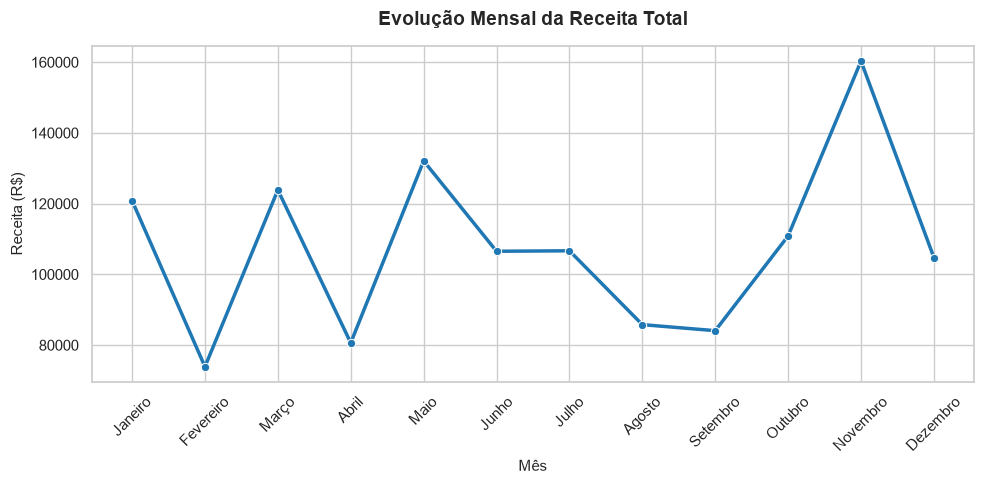

C:\Users\fajar\AppData\Local\Temp\ipykernel_29064\2316839767.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


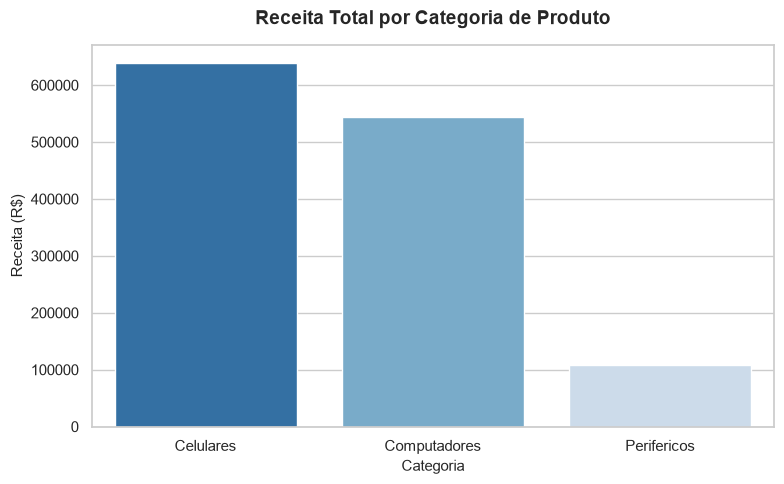

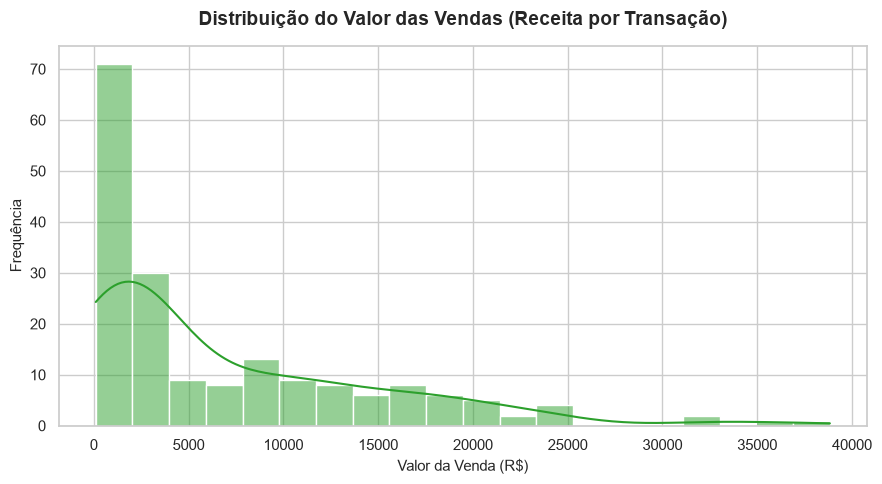

C:\Users\fajar\AppData\Local\Temp\ipykernel_29064\2316839767.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


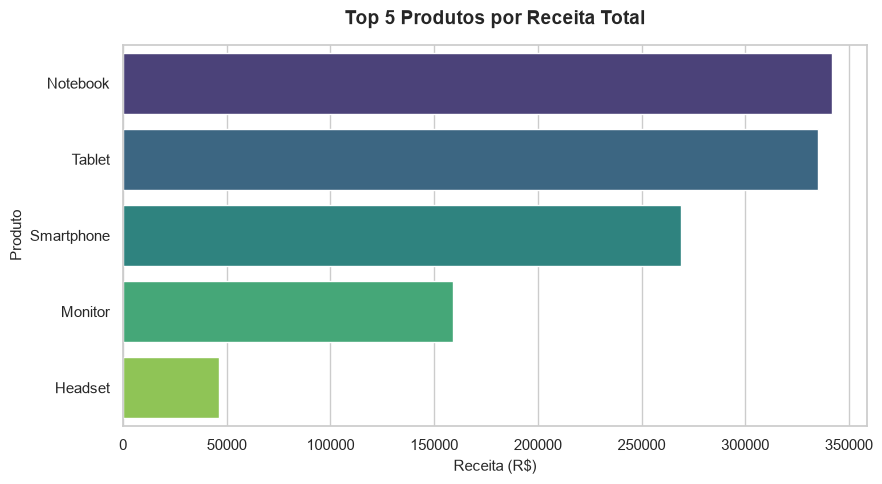


Visualizações geradas e salvas em PNG com sucesso!


In [97]:
# -------------------------------------------------------------------------
# Célula isolada de teste para o RF08
# -------------------------------------------------------------------------
metricas = calcular_metricas(df_processado)
gerar_visualizacoes(df_processado, metricas)

### Etapa 8: Estruturação Orientada a Objetos e Exposição da API e Exportação de Resultados (ETL - Load)

<h5 style="color: #7ac1f4;">
RF09 – Organizar o Código em Funções Reutilizáveis e em uma Classe <br>
RF10 – Exportar Resultados em CSV e JSON
</h5>

In [98]:
# =============================================================================
# RF09 – Estrutura Orientada a Objetos (AnalisadorDeVendas)
# =============================================================================

class AnalisadorDeVendas:
    """
    Encapsula o fluxo de análise dos dados de vendas.
    
    Esta classe organiza todo o pipeline em etapas sequenciais (carga, limpeza,
    transformação, análise e visualização), guardando o estado dos dados em
    atributos de instância e reaproveitando as funções já criadas.
    """

    def __init__(self, caminho_arquivo):
        """
        Construtor da classe.
        Recebe o caminho do arquivo e inicializa os atributos de estado.
        """
        self.caminho_arquivo = caminho_arquivo
        self.df_bruto = None
        self.df_limpo = None
        self.metricas = {}
        self.clientes = None
        self.relatorio_limpeza = {}
        self.estatisticas_numpy = {}

    def carregar(self):
        """Lê o CSV e guarda o DataFrame bruto (RF01)."""
        print("[RF01] Carregando dataset...")
        self.df_bruto = pd.read_csv(self.caminho_arquivo)
        print(f" -> [Analisador] {len(self.df_bruto)} registros lidos com sucesso.")
        return self.df_bruto

    def limpar(self):
        """Limpa e padroniza os dados reaproveitando a função limpar_dados() (RF03)."""
        print("\n[RF03] Limpando dados...")
        # Utiliza .copy() para preservar o DataFrame bruto original
        self.df_limpo, self.relatorio_limpeza = limpar_dados(self.df_bruto.copy())
        print(" -> Dados limpos e padronizados.")
        return self.df_limpo

    def transformar(self):
        """Cria as colunas derivadas reaproveitando criar_colunas_derivadas() (RF04)."""
        print("\n[RF04] Criando colunas derivadas...")
        self.df_limpo = criar_colunas_derivadas(self.df_limpo)
        print(" -> Colunas temporais e calculadas adicionadas.")
        return self.df_limpo

    def analisar(self):
        """Calcula métricas, segmentação e operações NumPy (RF05, RF06 e RF07)."""
        print("\n[RF05, RF06, RF07] Executando análises estatísticas...")
        
        # Reaproveita as funções procedimentais existentes
        self.metricas = calcular_metricas(self.df_limpo)
        self.clientes = segmentar_clientes(self.df_limpo)
        self.estatisticas_numpy = calcular_estatisticas_numpy(self.df_limpo)
        
        print(" -> Agregações e segmentação calculadas.")
        return self.metricas

    def visualizar(self):
        """Gera e exporta os 4 gráficos chamando gerar_visualizacoes() (RF08)."""
        print("\n[RF08] Gerando e salvando gráficos em PNG...")
        gerar_visualizacoes(self.df_limpo, self.metricas)

    def resumo(self):
        """Imprime no console um resumo executivo de tudo o que foi processado."""
        print("\n==================================================")
        print("             RESUMO EXECUTIVO DO PIPELINE          ")
        print("==================================================")
        print(f" Total de linhas brutas lidas : {len(self.df_bruto) if self.df_bruto is not None else 0}")
        print(f" Total de linhas processadas  : {len(self.df_limpo) if self.df_limpo is not None else 0}")
        
        if "receita_total" in self.df_limpo.columns:
            total_rec = self.df_limpo["receita_total"].sum()
            print(f" Receita Total do Período     : R$ {total_rec:,.2f}")
            
        print(f" Total de Clientes Analisados : {len(self.clientes) if self.clientes is not None else 0}")
        print(" Pasta das imagens geradas    : ../outputs/graficos/")
        print("==================================================\n")

    # =============================================================================
    # RF10 – Exportação de Resultados (Método a ser adicionado na classe)
    # =============================================================================

    def exportar(self, pasta_saida="../outputs"):
        """RF10: Persiste os datasets processados em CSV e as métricas em JSON."""
        print("\n[RF10] Exportando relatórios e datasets finais...")
        
        os.makedirs(pasta_saida, exist_ok=True)
        
        # 1. Exporta o CSV
        caminho_csv = os.path.join(pasta_saida, "vendas_processado.csv")
        self.df_limpo.to_csv(caminho_csv, index=False)
        print(f" -> Dataset processado salvo em: {caminho_csv}")

        # 2. Prepara o dicionário simples
        # Se você quiser remover o array escalonado, basta usar .pop() ou excluí-lo diretamente
        dados_estatisticos = self.estatisticas_numpy.copy()
        dados_estatisticos.pop("array_escalonado", None)  # Remove o array de forma simples

        resumo = {
            "total_registros_brutos": len(self.df_bruto) if self.df_bruto is not None else 0,
            "total_registros_limpos": len(self.df_limpo) if self.df_limpo is not None else 0,
            "receita_total": self.df_limpo["receita_total"].sum() if self.df_limpo is not None else 0.0,
            "estatisticas_numpy": dados_estatisticos
        }

        # 3. Exporta para JSON usando 'default=float' ou 'default=str'
        caminho_json = os.path.join(pasta_saida, "relatorio_final.json")
        with open(caminho_json, "w", encoding="utf-8") as f:
            json.dump(resumo, f, indent=4, ensure_ascii=False, default=float)
            
        print(f" -> Relatório executivo salvo em: {caminho_json}")

    def executar_pipeline(self):
        """Método principal que roda todas as etapas em sequência."""
        self.carregar()
        self.limpar()
        self.transformar()
        self.analisar()
        self.visualizar()
        self.exportar()  # <-- Adicionado o RF10 no fluxo
        self.resumo()

[RF01] Carregando dataset...
 -> [Analisador] 200 registros lidos com sucesso.

[RF03] Limpando dados...
Relatório de Limpeza:
  registros_iniciais: 200
  registros_removidos: 17
  registros_finais: 183
 -> Dados limpos e padronizados.

[RF04] Criando colunas derivadas...
 -> Colunas temporais e calculadas adicionadas.

[RF05, RF06, RF07] Executando análises estatísticas...
 -> Agregações e segmentação calculadas.

[RF08] Gerando e salvando gráficos em PNG...


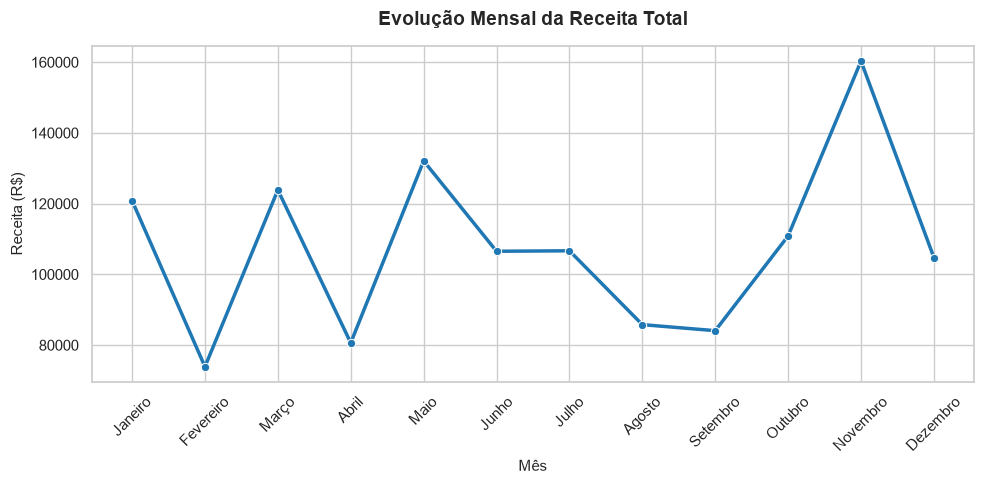

C:\Users\fajar\AppData\Local\Temp\ipykernel_29064\2316839767.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


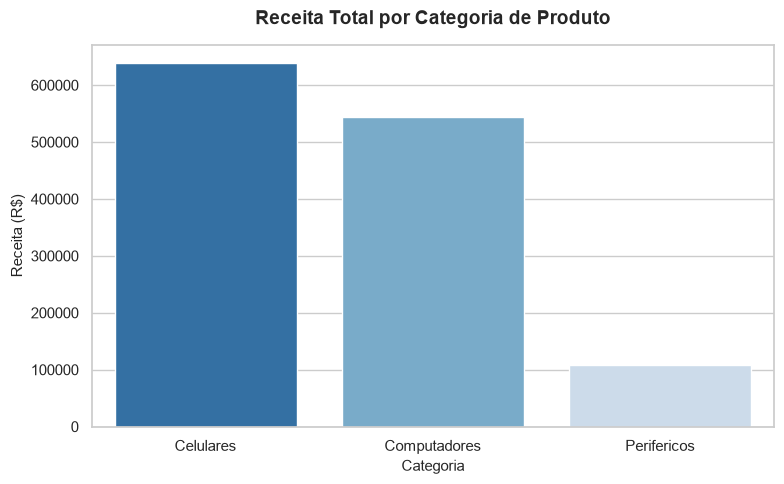

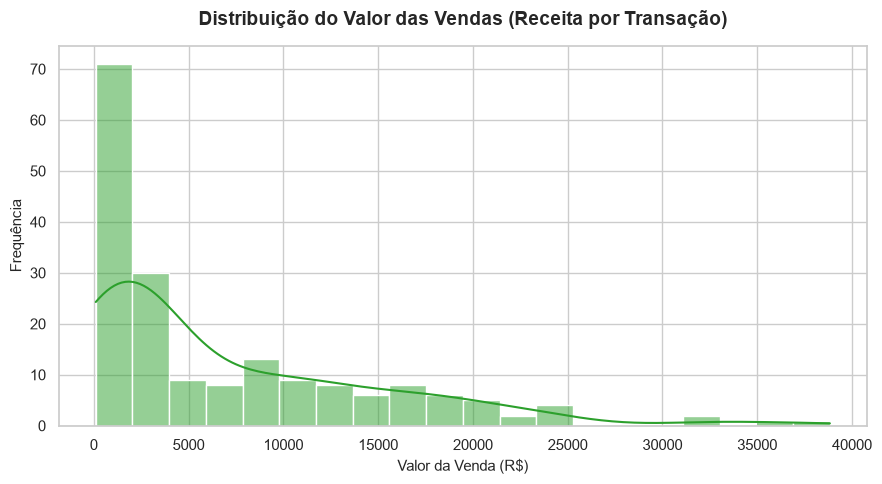

C:\Users\fajar\AppData\Local\Temp\ipykernel_29064\2316839767.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


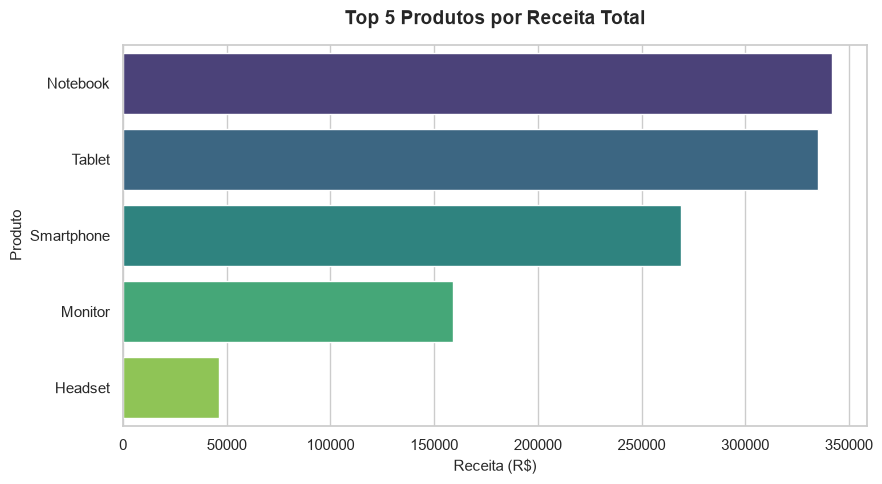


Visualizações geradas e salvas em PNG com sucesso!

[RF10] Exportando relatórios e datasets finais...
 -> Dataset processado salvo em: ../outputs\vendas_processado.csv
 -> Relatório executivo salvo em: ../outputs\relatorio_final.json

             RESUMO EXECUTIVO DO PIPELINE          
 Total de linhas brutas lidas : 200
 Total de linhas processadas  : 183
 Receita Total do Período     : R$ 1,290,346.30
 Total de Clientes Analisados : 58
 Pasta das imagens geradas    : ../outputs/graficos/



In [99]:
# -------------------------------------------------------------------------
# Teste para o RF09 & RF10
# -------------------------------------------------------------------------

# Instancia a classe apontando para a sua base de dados
analisador = AnalisadorDeVendas("../databases/vendas.csv")

# Executa o pipeline completo de uma só vez
analisador.executar_pipeline()

### Etapa 9: Execução Final e Entrega do Projeto


<h5 style="color: #7ac1f4;">
RF11 – Executar o Fluxo Completo (Ponto de Entrada)
</h5>

   SALESINSIGHT PY - Análise de Dados de Vendas
[RF01] Carregando dataset...
 -> [Analisador] 200 registros lidos com sucesso.
=== INSPEÇÃO INICIAL DO DATASET ===
Shape: O dataframe tem [200] linhas e [8] colunas.

Primeiras 5 linhas:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2025-05-21,cliente#016,Mouse,Perifericos,Sudeste,2.0,102.90
1,2,2025-09-16,Cliente_039,Notebook,Computadores,Norte,NaN,3204.57
2,3,2025-03-23,Cliente_045,Tablet,Celulares,Centro-Oeste,1.0,1939.76
3,4,2025-11-06,Cliente_017,Notebook,Computadores,Norte,6.0,3864.87
4,5,2025-07-05,Cliente_037,Tablet,Celulares,Sul,10.0,2008.14



Últimas 5 linhas:


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
195,196,2025-06-04,CLIENTE-038,Monitor,Computadores,Centro-Oeste,5.0,NaN
196,197,2025-09-15,Cliente_046,Tablet,Celulares,Sul,3.0,1748.92
197,198,2025-08-21,Cliente_048,Smartphone,Celulares,Sul,3.0,2185.60
198,199,2025-11-02,Cliente_006,Headset,Perifericos,Norte,4.0,368.94
199,200,2025-03-18,Cliente_011,Teclado,Perifericos,Sudeste,4.0,255.45



Tipos das colunas:


,Tipo de Dado
id_venda,int64
data_venda,str
cliente,str
produto,str
categoria,str
regiao,str
quantidade,float64
preco_unitario,float64



Valores nulos por coluna:


,Qtd Nulos
id_venda,0
data_venda,0
cliente,0
produto,0
categoria,0
regiao,0
quantidade,10
preco_unitario,4



[RF03] Limpando dados...
Relatório de Limpeza:
  registros_iniciais: 200
  registros_removidos: 17
  registros_finais: 183
 -> Dados limpos e padronizados.

[RF04] Criando colunas derivadas...
 -> Colunas temporais e calculadas adicionadas.

[RF05, RF06, RF07] Executando análises estatísticas...
 -> Agregações e segmentação calculadas.

[RF08] Gerando e salvando gráficos em PNG...


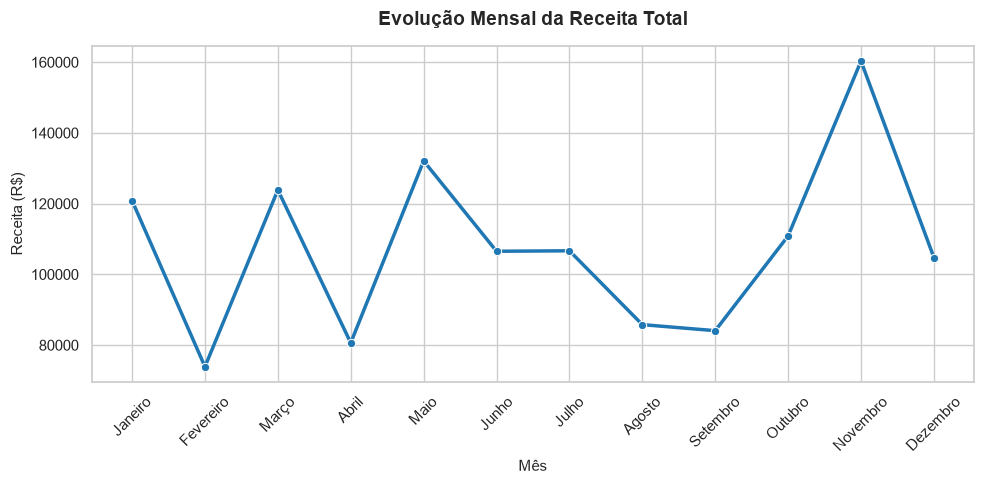

C:\Users\fajar\AppData\Local\Temp\ipykernel_29064\2316839767.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


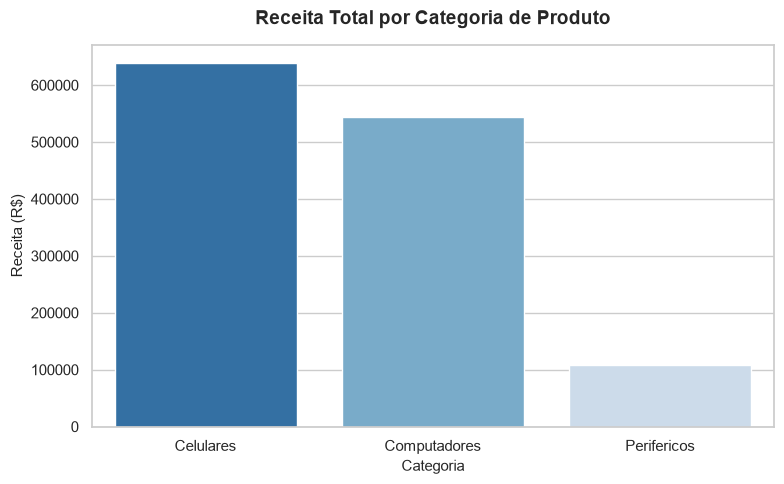

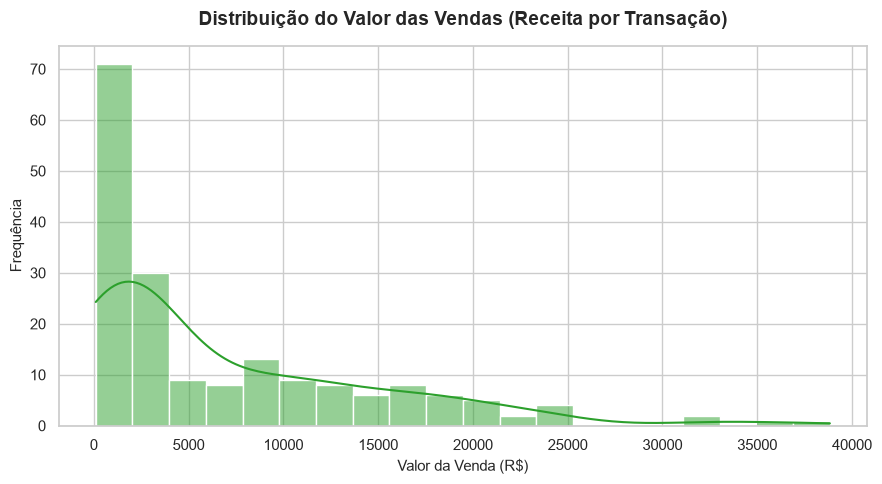

C:\Users\fajar\AppData\Local\Temp\ipykernel_29064\2316839767.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


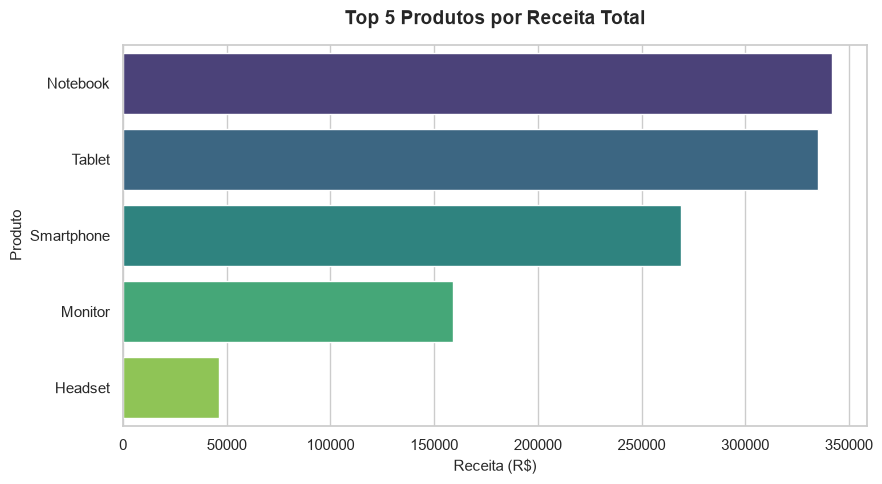


Visualizações geradas e salvas em PNG com sucesso!

[RF10] Exportando relatórios e datasets finais...
 -> Dataset processado salvo em: ../outputs\vendas_processado.csv
 -> Relatório executivo salvo em: ../outputs\relatorio_final.json

             RESUMO EXECUTIVO DO PIPELINE          
 Total de linhas brutas lidas : 200
 Total de linhas processadas  : 183
 Receita Total do Período     : R$ 1,290,346.30
 Total de Clientes Analisados : 58
 Pasta das imagens geradas    : ../outputs/graficos/


[CONCLUÍDO] Fluxo finalizado com sucesso. Todos os entregáveis foram gerados.


In [100]:
# =============================================================================
# RF11 – Executar o Fluxo Completo (Ponto de Entrada)
# =============================================================================

def main():
    """Executa o fluxo completo do SalesInsight PY de ponta a ponta."""
    print("=" * 60)
    print("   SALESINSIGHT PY - Análise de Dados de Vendas")
    print("=" * 60)

    # Etapa 0: Garante a existência do arquivo de dados antes da execução
    caminho_dados = "../databases/vendas.csv"  # Ajuste o caminho se o arquivo estiver em ../databases/
    
    if not os.path.exists(caminho_dados):
        print(f"[Aviso] Arquivo '{caminho_dados}' não encontrado. Gerando dataset...")
        df_gerado = gerar_dataset_vendas()
        df_gerado.to_csv(caminho_dados, index=False)
        print(" -> Dataset inicial criado com sucesso.")

    # Etapas 1 a 6: Orquestração estrita via Classe AnalisadorDeVendas
    analisador = AnalisadorDeVendas(caminho_dados)
    
    # 1. Carregamento bruto (RF01)
    analisador.carregar()
    
    # Inspeção inicial dos dados brutos (RF02)
    inspecionar_dados(analisador.df_bruto)
    
    # 2. Limpeza e padronização com RegEx (RF03) -> DEVE VIR ANTES de qualquer transformação!
    analisador.limpar()
    
    # 3. Engenharia de recursos e colunas derivadas (RF04)
    analisador.transformar()
    
    # 4. Agregações, segmentações e métricas NumPy (RF05, RF06, RF07)
    analisador.analisar()
    
    # 5. Geração de gráficos PNG (RF08)
    analisador.visualizar()
    
    # 6. Exportação dos datasets (CSV) e relatórios (JSON) (RF10)
    analisador.exportar()
    
    # Exibição do resumo final no terminal
    analisador.resumo()

    print("\n[CONCLUÍDO] Fluxo finalizado com sucesso. Todos os entregáveis foram gerados.")


# Ponto de entrada padrão do script Python
if __name__ == "__main__":
    main()